# NB01 — Primary PGLS: Metal-Gene Density → Niche Breadth

**Type:** Confirmatory (pre-registered as P1 + P2 in RESEARCH_PLAN.md §3)  
**Status:** READY TO RUN  

## Pre-specification

- **Response:** `mean_levins_B_std` (genus-level Levins' standardised niche breadth, from genus_trait_table.csv)
- **Primary predictor (P1):** `ko_per_mb_primary` — KO density for the Tier 1+2 primary gene subset (140 KOs), z-scored
- **Tree:** `data/gtdb_bac_genus_pruned.tree` (GTDB, 2283 bacteria)
- **Secondary (P2):** Repeat with Archaea tree
- **Significance:** α = 0.05 FDR-adjusted across P1+P2+P3 jointly
- **Minimum n:** 100 genera

## Data path

The preferred predictor (`ko_per_mb_primary`) requires per-MAG KO assignments from BERDL.  
A BERDL Spark block is provided below (Block 2A); if running offline, Block 2B uses the  
legacy `mgnify_mag_ko_density.csv` with `ko_per_mb_total` (all old metal KOs, ~200 KOs)  
as a documented fallback. The analysis label records which path was used.

**Results go to:** `data/01_primary_pgls_results.csv` and INTERPRETATION_TABLE.md §1.


In [1]:
import sys
from pathlib import Path

_project_root = Path().resolve().parent
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import dendropy

from scripts.gene_list_utils import load_gene_list, get_subset, get_ko_set
from scripts.pgls_utils import run_pgls, pgls_results_table, fdr_correct, load_tree
from scripts.berdl_utils import get_spark_session

DATA = _project_root / 'data'
FIGURES = _project_root / 'figures'
TREE_BAC = DATA / 'gtdb_bac_genus_pruned.tree'
TREE_ARC = DATA / 'gtdb_arc_genus_pruned.tree'

pd.set_option('display.max_rows', 80)
print('Imports OK')

Imports OK


## Block 1 — Load gene list and define KO sets

In [2]:
gl = load_gene_list(DATA / 'curated_mrg_ko_ids_v2.csv')

PRIMARY_KOS  = get_ko_set('primary', gl)          # Tier1+Tier2, n=140
TIER1_KOS    = get_ko_set('tier1_only', gl)        # n=32

print(f'Primary KO set (Tier1+2): {len(PRIMARY_KOS)}')
print(f'Tier-1 only:              {len(TIER1_KOS)}')

Primary KO set (Tier1+2): 140
Tier-1 only:              32


## Block 2A — BERDL Spark path (preferred; run in JupyterHub)

Queries `kbase.ke_pangenome.eggnog_mapper_annotations` → gene clusters → GTDB taxonomy  
to count distinct primary-set KOs present per genus, then normalises by mean genome size.

**If this block fails, skip to Block 2B.**

In [3]:
_SPARK_AVAILABLE = False
spark = None

try:
    spark = get_spark_session()
    _SPARK_AVAILABLE = True
    print('Spark session acquired.')
except Exception as exc:
    print(f'Spark not available: {exc}')
    print('>>> Using local fallback (Block 2B).')

[berdl_utils] JupyterHub SparkSession acquired: 4.0.1
Spark session acquired.


In [4]:
genus_ko_spark = None

if _SPARK_AVAILABLE:
    ko_in_list = ', '.join(f"'{k}'" for k in sorted(PRIMARY_KOS))

    # Step 1: Explode KEGG_ko, strip "ko:" prefix, filter to our list
    spark.sql(f"""
        CREATE OR REPLACE TEMP VIEW ego_exploded AS
        SELECT
            ego.query_name,
            TRIM(REPLACE(TRIM(ko_part), 'ko:', '')) AS kegg_ko_single
        FROM kbase.ke_pangenome.eggnog_mapper_annotations ego
        LATERAL VIEW explode(split(ego.KEGG_ko, '[|,]')) ko AS ko_part
        WHERE TRIM(ko_part) != '-'
          AND TRIM(ko_part) != ''
          AND TRIM(REPLACE(TRIM(ko_part), 'ko:', '')) IN ({ko_in_list})
    """)

    # Step 2: Join to gene cluster, genome, taxonomy
    spark.sql("""
        CREATE OR REPLACE TEMP VIEW genus_primary_ko_counts AS
        SELECT
            LOWER(REGEXP_REPLACE(SPLIT(tax.genus, '__')[1], ' ', '_')) AS genus_lower,
            COUNT(DISTINCT ego_ex.kegg_ko_single) AS n_ko_primary
        FROM ego_exploded ego_ex
        JOIN kbase.ke_pangenome.gene_genecluster_junction junc
          ON ego_ex.query_name = junc.gene_id
        JOIN kbase.ke_pangenome.gene_cluster gc
          ON junc.gene_cluster_id = gc.gene_cluster_id
        JOIN kbase.ke_pangenome.genome g
          ON gc.gtdb_species_clade_id = g.gtdb_species_clade_id
        JOIN kbase.ke_pangenome.gtdb_taxonomy_r214v1 tax
          ON g.genome_id = tax.genome_id
        GROUP BY LOWER(REGEXP_REPLACE(SPLIT(tax.genus, '__')[1], ' ', '_'))
    """)

    genus_ko_counts = spark.sql("SELECT * FROM genus_primary_ko_counts").toPandas()
    print(f'KO counts: {len(genus_ko_counts)} genera')

    # Step 3: Merge with existing genome size data
    genome_size = pd.read_csv(
        '/home/hmacgregor/BERIL-research-observatory/projects/microbeatlas_metal_ecology/data/genus_genome_size_gtdb.csv'
    )
    print(f'Genome sizes: {len(genome_size)} genera')

    genus_ko_spark = genus_ko_counts.merge(genome_size, on='genus_lower', how='inner')
    genus_ko_spark['mean_genome_mb'] = genus_ko_spark['mean_genome_size_bp'] / 1e6
    genus_ko_spark['ko_per_mb_primary'] = genus_ko_spark['n_ko_primary'] / genus_ko_spark['mean_genome_mb']

    print(f'BERDL path: {len(genus_ko_spark)} genera with primary KO data + genome sizes')
    genus_ko_spark.to_csv(DATA / '01_genus_ko_density_spark.csv', index=False)
    print('Saved: data/01_genus_ko_density_spark.csv')

KO counts: 8256 genera
Genome sizes: 8419 genera
BERDL path: 8256 genera with primary KO data + genome sizes
Saved: data/01_genus_ko_density_spark.csv


## Block 2B — Local MAG fallback

Uses `mgnify_mag_ko_density.csv`. **Note:** `ko_per_mb_total` here = all KOs from the *old* (~200-KO) metal gene set,  
not the new primary 140-KO subset. Documented as `ko_per_mb_total_legacy` in results.

In [5]:
mag_kd = pd.read_csv(DATA / 'mgnify_mag_ko_density.csv')
mag_kd['genus_lower'] = mag_kd['genus'].str.lower().str.strip()

genus_kd_legacy = mag_kd.groupby('genus_lower').agg(
    n_mags=('genome_id', 'count'),
    ko_per_mb_total_legacy=('ko_per_mb_total', 'mean'),
    mean_genome_mb=('genome_length_mb', 'mean'),
).reset_index()

print(f'Legacy: {len(genus_kd_legacy)} genera from {len(mag_kd):,} MAGs')
print(genus_kd_legacy['ko_per_mb_total_legacy'].describe())

Legacy: 7541 genera from 260,652 MAGs
count    7541.000000
mean        4.831809
std         3.732789
min         0.000000
25%         2.154049
50%         4.436827
75%         6.711523
max        36.161855
Name: ko_per_mb_total_legacy, dtype: float64


## Block 3 — Select predictor and build PGLS input

In [6]:
# Select predictor source
if genus_ko_spark is not None and len(genus_ko_spark) > 200:
    genus_pred = genus_ko_spark[['genus_lower', 'ko_per_mb_primary', 'mean_genome_mb']].copy()
    PREDICTOR_COL   = 'ko_per_mb_primary'
    PREDICTOR_LABEL = 'ko_per_mb_primary_z (BERDL kbase.ke_pangenome, 140 KOs Tier1+2)'
    DATA_PATH_USED  = 'BERDL Spark (kbase.ke_pangenome)'
else:
    genus_pred = genus_kd_legacy[['genus_lower', 'ko_per_mb_total_legacy', 'mean_genome_mb']].rename(
        columns={'ko_per_mb_total_legacy': 'ko_per_mb_primary'}
    ).copy()
    PREDICTOR_COL   = 'ko_per_mb_primary'
    PREDICTOR_LABEL = 'ko_per_mb_total_legacy_z (mgnify_mag_ko_density.csv, old ~200-KO set — FALLBACK)'
    DATA_PATH_USED  = 'Local fallback: mgnify_mag_ko_density.csv (old classification)'

print(f'Using: {DATA_PATH_USED}')
print(f'Predictor: {PREDICTOR_LABEL}')

Using: BERDL Spark (kbase.ke_pangenome)
Predictor: ko_per_mb_primary_z (BERDL kbase.ke_pangenome, 140 KOs Tier1+2)


In [7]:
# Load response
gt = pd.read_csv(DATA / 'genus_trait_table.csv')
gt_sub = gt[['genus_lower', 'mean_levins_B_std', 'phylum', 'kingdom']].dropna(subset=['mean_levins_B_std'])
print(f'Trait table (n with levins_B_std): {len(gt_sub)}')

# Tree genera
bac_tree = dendropy.Tree.get(path=str(TREE_BAC), schema='newick', preserve_underscores=True)
bac_labels = {leaf.taxon.label.lower() for leaf in bac_tree.leaf_node_iter()}
print(f'Bac tree tips: {len(bac_labels)}')

# Build and filter
pgls_df = genus_pred.merge(gt_sub, on='genus_lower', how='inner')
pgls_df = pgls_df.dropna(subset=[PREDICTOR_COL, 'mean_levins_B_std'])

pgls_bac = pgls_df[pgls_df['genus_lower'].isin(bac_labels)].copy()

# Z-score predictor (bacteria subset)
mu, sd = pgls_bac[PREDICTOR_COL].mean(), pgls_bac[PREDICTOR_COL].std(ddof=1)
pgls_bac['predictor_z'] = (pgls_bac[PREDICTOR_COL] - mu) / sd

# Genome size z (confounder check)
pgls_bac['genome_mb_z'] = (pgls_bac['mean_genome_mb'] - pgls_bac['mean_genome_mb'].mean()) / pgls_bac['mean_genome_mb'].std(ddof=1)

print(f'PGLS-ready bacteria: {len(pgls_bac)}')
assert len(pgls_bac) >= 100, f'n={len(pgls_bac)} < 100 — check data'
pgls_bac.to_csv(DATA / '01_pgls_input_bacteria.csv', index=False)
print('Saved: data/01_pgls_input_bacteria.csv')

Trait table (n with levins_B_std): 2851
Bac tree tips: 2283
PGLS-ready bacteria: 1574
Saved: data/01_pgls_input_bacteria.csv


## Block 4 — Descriptive checks

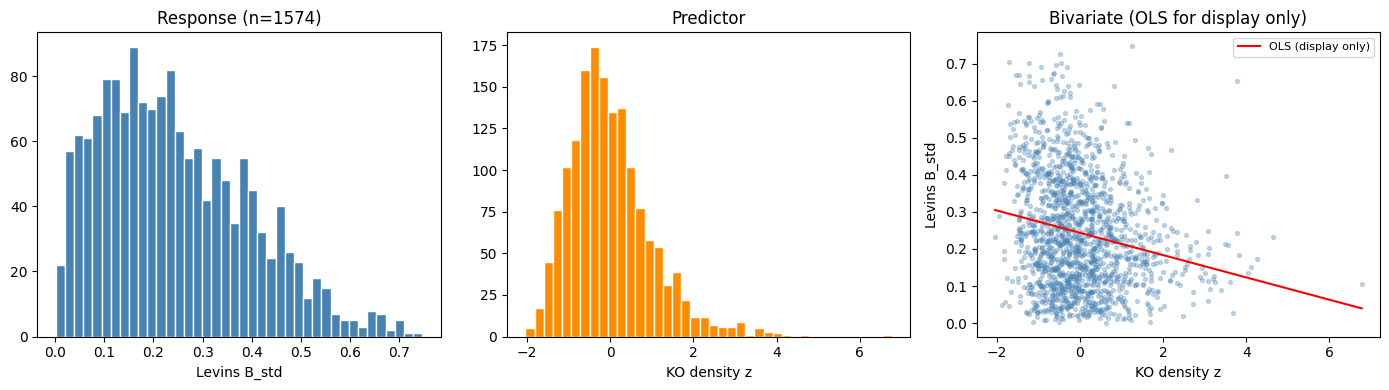

OLS Pearson r (unadjusted for phylogeny): -0.200


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(pgls_bac['mean_levins_B_std'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Levins B_std'); axes[0].set_title(f'Response (n={len(pgls_bac)})')

axes[1].hist(pgls_bac['predictor_z'].dropna(), bins=40, color='darkorange', edgecolor='white')
axes[1].set_xlabel('KO density z'); axes[1].set_title('Predictor')

axes[2].scatter(pgls_bac['predictor_z'], pgls_bac['mean_levins_B_std'], alpha=0.3, s=8, color='steelblue')
xr = np.linspace(pgls_bac['predictor_z'].min(), pgls_bac['predictor_z'].max(), 100)
m = np.polyfit(pgls_bac['predictor_z'], pgls_bac['mean_levins_B_std'], 1)
axes[2].plot(xr, np.polyval(m, xr), 'r-', lw=1.5, label='OLS (display only)')
axes[2].set_xlabel('KO density z'); axes[2].set_ylabel('Levins B_std')
axes[2].set_title('Bivariate (OLS for display only)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / '01_descriptive.png', dpi=150, bbox_inches='tight')
plt.show()

r_ols = pgls_bac[['predictor_z', 'mean_levins_B_std']].corr().iloc[0, 1]
print(f'OLS Pearson r (unadjusted for phylogeny): {r_ols:.3f}')

## Block 5 — Primary PGLS: Bacteria (Test P1)

In [9]:
print(f'Running P1: Bacteria, primary gene set (n={len(pgls_bac)})...')

res_p1 = run_pgls(
    df=pgls_bac,
    tree_path=TREE_BAC,
    response='mean_levins_B_std',
    predictors=['predictor_z'],
    taxon_col='genus_lower',
    label='P1_bacteria_primary',
    min_n=100,
)

print('=== P1 RESULT ===')
for k in ['n', 'lambda_est', 'beta', 'SE', 't_stat', 'p_value', 'r2', 'delta_aic_vs_null']:
    print(f'  {k:20s} = {res_p1.get(k)}')

Running P1: Bacteria, primary gene set (n=1574)...


/home/hmacgregor/.local/lib/python3.13/site-packages/dendropy/datamodel/treemodel/_tree.py:1510: UserWarning: Calculating MRCA on an unrooted tree implicitly implicitly treats seed node as root. Set tree.is_rooted = True to silence this warning.
  warnings.warn(


=== P1 RESULT ===
  n                    = 1574
  lambda_est           = 0.7566
  beta                 = -0.020700436499362016
  SE                   = 0.003677270224372243
  t_stat               = -5.62929435051128
  p_value              = 2.139300558923196e-08
  r2                   = 0.045610994953735995
  delta_aic_vs_null    = -29.41


## Block 6 — Archaea replication (Test P2)

In [10]:
arc_tree = dendropy.Tree.get(path=str(TREE_ARC), schema='newick', preserve_underscores=True)
arc_labels = {leaf.taxon.label.lower() for leaf in arc_tree.leaf_node_iter()}
print(f'Archaea tree tips: {len(arc_labels)}')

pgls_arc = pgls_df[pgls_df['genus_lower'].isin(arc_labels)].copy()
if len(pgls_arc) > 0:
    pgls_arc['predictor_z'] = (pgls_arc[PREDICTOR_COL] - pgls_arc[PREDICTOR_COL].mean()) / pgls_arc[PREDICTOR_COL].std(ddof=1)

print(f'Archaea PGLS-ready genera: {len(pgls_arc)}')

if len(pgls_arc) >= 30:
    res_p2 = run_pgls(
        df=pgls_arc,
        tree_path=TREE_ARC,
        response='mean_levins_B_std',
        predictors=['predictor_z'],
        taxon_col='genus_lower',
        label='P2_archaea_primary',
        min_n=30,
    )
    print(f"P2: n={res_p2['n']}, lambda={res_p2['lambda_est']:.4f}, beta={res_p2['beta']:+.4f}, p={res_p2['p_value']:.4g}")
else:
    res_p2 = {'label': 'P2_archaea_primary', 'converged': False,
               'error': f'n={len(pgls_arc)} below threshold 30'}
    print(f"P2 skipped: {res_p2['error']}")

Archaea tree tips: 129
Archaea PGLS-ready genera: 95
P2: n=95, lambda=0.7260, beta=-0.0137, p=0.1188


/home/hmacgregor/.local/lib/python3.13/site-packages/dendropy/datamodel/treemodel/_tree.py:1510: UserWarning: Calculating MRCA on an unrooted tree implicitly implicitly treats seed node as root. Set tree.is_rooted = True to silence this warning.
  warnings.warn(


## Block 7 — FDR across P1 + P2 (P3 from NB02 pending)

In [11]:
# Collect raw p-values (P3 placeholder = NaN)
p_raw = {'P1_bacteria_primary': res_p1.get('p_value', np.nan),
         'P2_archaea_primary':  res_p2.get('p_value', np.nan)}

valid_idx = [(k, v) for k, v in p_raw.items() if not np.isnan(v)]
if valid_idx:
    adj = fdr_correct([v for _, v in valid_idx])
    p_fdr = {k: float(a) for (k, _), a in zip(valid_idx, adj)}
    p_fdr.update({k: np.nan for k in p_raw if k not in p_fdr})
else:
    p_fdr = {k: np.nan for k in p_raw}

print('FDR-adjusted p-values (P1+P2 only; P3 will be added after NB02):')
for k, v in p_fdr.items():
    print(f'  {k}: {v:.4g}')

print()
print('NOTE: re-run FDR correction after NB02 completes to include P3.')

FDR-adjusted p-values (P1+P2 only; P3 will be added after NB02):
  P1_bacteria_primary: 4.279e-08
  P2_archaea_primary: 0.1188

NOTE: re-run FDR correction after NB02 completes to include P3.


## Block 8 — Save results

In [12]:
results_list = [r for r in [res_p1, res_p2] if r.get('converged', False)]
results_df = pgls_results_table(results_list)
results_df['p_fdr'] = results_df['label'].map(p_fdr)
results_df['significant_fdr05'] = results_df['p_fdr'] < 0.05
results_df['predictor_source'] = DATA_PATH_USED
results_df['predictor_label'] = PREDICTOR_LABEL

results_df.to_csv(DATA / '01_primary_pgls_results.csv', index=False)
print('Saved: data/01_primary_pgls_results.csv')
display(results_df)

Saved: data/01_primary_pgls_results.csv


,label,response,predictor,n,lambda_est,beta,SE,t_stat,p_value,r2,delta_aic_vs_null,p_fdr,significant_fdr05,predictor_source,predictor_label
0,P1_bacteria_primary,mean_levins_B_std,predictor_z,1574,0.7566,-0.020700,0.003677,-5.629294,2.139301e-08,0.045611,-29.41,4.278601e-08,True,BERDL Spark (kbase.ke_pangenome),"ko_per_mb_primary_z (BERDL kbase.ke_pangenome,..."
1,P2_archaea_primary,mean_levins_B_std,predictor_z,95,0.7260,-0.013734,0.008724,-1.574263,1.188225e-01,0.063436,-0.48,1.188225e-01,False,BERDL Spark (kbase.ke_pangenome),"ko_per_mb_primary_z (BERDL kbase.ke_pangenome,..."


## Block 9 — Figure

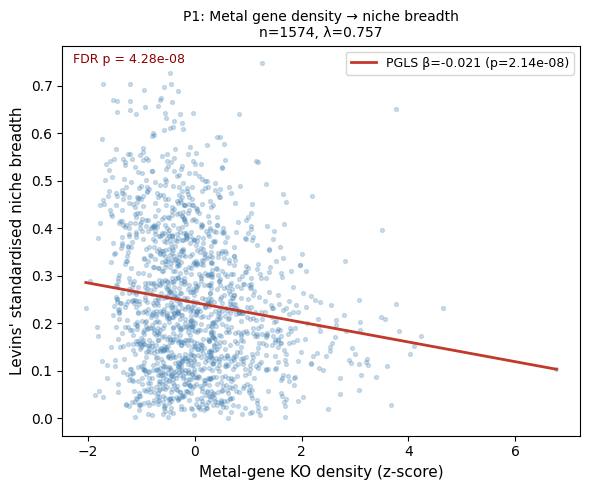

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(pgls_bac['predictor_z'], pgls_bac['mean_levins_B_std'],
           alpha=0.25, s=8, color='steelblue')

if res_p1.get('converged', False):
    b = res_p1['beta']
    intercept = pgls_bac['mean_levins_B_std'].mean() - b * pgls_bac['predictor_z'].mean()
    xr = np.linspace(pgls_bac['predictor_z'].min(), pgls_bac['predictor_z'].max(), 100)
    ax.plot(xr, intercept + b * xr, color='#c0392b', lw=2,
            label=f"PGLS β={b:+.3f} (p={res_p1['p_value']:.3g})")

ax.set_xlabel('Metal-gene KO density (z-score)', fontsize=11)
ax.set_ylabel("Levins' standardised niche breadth", fontsize=11)
ax.set_title(f"P1: Metal gene density → niche breadth\n"
             f"n={res_p1.get('n','?')}, λ={res_p1.get('lambda_est','?'):.3f}", fontsize=10)
ax.legend(fontsize=9)

fdr_p1 = p_fdr.get('P1_bacteria_primary', np.nan)
if not np.isnan(fdr_p1):
    ax.text(0.02, 0.98, f'FDR p = {fdr_p1:.3g}', transform=ax.transAxes,
            va='top', ha='left', fontsize=9, color='darkred')

plt.tight_layout()
plt.savefig(FIGURES / '01_pgls_primary_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Block 10 — REPORTING SUMMARY

Copy these values into INTERPRETATION_TABLE.md §1 (rows P1 and P2).

In [ ]:
print('=== NB01 REPORTING SUMMARY ===')
print(f'Data source:   {DATA_PATH_USED}')
print(f'Predictor:     {PREDICTOR_LABEL}')
print()
print('--- P1 (Bacteria) ---')
for k in ['n', 'lambda_est', 'beta', 'SE', 't_stat', 'p_value', 'r2', 'delta_aic_vs_null']:
    print(f'  {k:25s} = {res_p1.get(k)}')
print(f'  p_fdr (P1+P2 only, pending P3) = {p_fdr.get("P1_bacteria_primary", "N/A")}')

beta_p1 = res_p1.get('beta', 0)
p_p1_fdr = p_fdr.get('P1_bacteria_primary', 1.0)
if beta_p1 < 0 and not np.isnan(p_p1_fdr) and p_p1_fdr < 0.05:
    verdict = 'SUPPORT for H1 (β < 0, FDR p < 0.05)'
elif beta_p1 < 0:
    verdict = 'Negative but non-significant — H0 not rejected'
elif not np.isnan(p_p1_fdr) and p_p1_fdr < 0.05:
    verdict = 'EVIDENCE AGAINST H1 (β ≥ 0, FDR p < 0.05)'
else:
    verdict = 'H0 not rejected (β ≥ 0, non-significant)'
print(f'  Interpretation: {verdict}')

if res_p2.get('converged', False):
    print()
    print('--- P2 (Archaea) ---')
    for k in ['n', 'lambda_est', 'beta', 'SE', 'p_value']:
        print(f'  {k:25s} = {res_p2.get(k)}')
    print(f'  p_fdr = {p_fdr.get("P2_archaea_primary", "N/A")}')
else:
    print(f'P2 (Archaea): {res_p2.get("error", "not run")}')

In [15]:
## Block 11 — Soil-restricted P1 sensitivity
# Soil specialists defined via MicrobeAtlas Env_Level_1 (same definition as microbeatlas NB14).
# A genus is soil-specialist if >50% of its OTUs have dominant Env_Level_1 ∈ SOIL_ENVS.
# Source: otu_env_matrix.csv (otu_id, Env_Level_1, n_samples_detected)
#       + otu_pangenome_link_v2.csv (otu_id → genus_lower)
# Predictor re-z-scored within soil subset.
# Expected: β < 0, consistent with microbeatlas NB14 (β=−0.023, p=0.0002, n=603).

print('=== P1 SOIL-RESTRICTED SENSITIVITY (MicrobeAtlas Env_Level_1) ===\n')

MICROBEATLAS = _project_root.parent / 'microbeatlas_metal_ecology' / 'data'
SOIL_ENVS = {'soil', 'agricultural', 'farm', 'field', 'paddy', 'peatland', 'desert', 'shrub'}

_otu_env  = pd.read_csv(MICROBEATLAS / 'otu_env_matrix.csv',
                         usecols=['otu_id', 'Env_Level_1', 'n_samples_detected'])
_otu_link = pd.read_csv(MICROBEATLAS / 'otu_pangenome_link_v2.csv',
                         usecols=['otu_id', 'genus_lower']).dropna(subset=['genus_lower'])

# Dominant Env_Level_1 per OTU (highest n_samples_detected)
_dom_env = (_otu_env.loc[_otu_env.groupby('otu_id')['n_samples_detected'].idxmax()]
            [['otu_id', 'Env_Level_1']].copy())
_dom_env['is_soil'] = _dom_env['Env_Level_1'].str.lower().isin(SOIL_ENVS)

# Genus-level soil fraction across its OTUs
_otu_genus_env = _dom_env.merge(_otu_link.drop_duplicates('otu_id'), on='otu_id', how='inner')
_genus_soil = (_otu_genus_env.groupby('genus_lower')['is_soil']
               .agg(['sum', 'count'])
               .assign(frac_soil=lambda x: x['sum'] / x['count'])
               .reset_index())
_soil_genera = set(_genus_soil.loc[_genus_soil['frac_soil'] > 0.5, 'genus_lower'])
print(f'Soil-specialist genera (MicrobeAtlas Env_Level_1, frac_soil > 0.5): {len(_soil_genera)}')

soil_pgls = pgls_bac[pgls_bac['genus_lower'].isin(_soil_genera)].copy()
soil_pgls['predictor_z'] = ((soil_pgls['ko_per_mb_primary'] - soil_pgls['ko_per_mb_primary'].mean())
                              / soil_pgls['ko_per_mb_primary'].std())
n_soil = soil_pgls.dropna(subset=['predictor_z', 'mean_levins_B_std']).shape[0]
print(f'Soil-restricted input: {n_soil} genera')

res_p1_soil = run_pgls(soil_pgls, TREE_BAC,
                        response='mean_levins_B_std',
                        predictors=['predictor_z'],
                        taxon_col='genus_lower',
                        label='P1_soil_restricted_microbeatlas',
                        min_n=50)

print(f'\nP1 soil-restricted (MicrobeAtlas):')
print(f'  n  = {res_p1_soil.get("n")}')
print(f'  β  = {res_p1_soil.get("beta", float("nan")):.5f}')
print(f'  SE = {res_p1_soil.get("se", float("nan")):.5f}')
print(f'  p  = {res_p1_soil.get("p_value", float("nan")):.3e}')
print(f'  λ  = {res_p1_soil.get("lambda_est", float("nan")):.3f}')
print(f'  r² = {res_p1_soil.get("r2", float("nan")):.4f}')
print(f'\n  cf. P1 (all biomes):          β={res_p1.get("beta", float("nan")):.5f}, '
      f'p={res_p1.get("p_value", float("nan")):.3e}, n={res_p1.get("n")}')
print(f'  cf. microbeatlas NB14 (soil): β=−0.023, p=0.00020, n=603')

pd.DataFrame([res_p1_soil]).to_csv(DATA / '01_soil_restricted_pgls_results.csv', index=False)
print('\nSaved: data/01_soil_restricted_pgls_results.csv')


=== P1 SOIL-RESTRICTED SENSITIVITY (MicrobeAtlas Env_Level_1) ===



Soil-specialist genera (MicrobeAtlas Env_Level_1, frac_soil > 0.5): 318
Soil-restricted input: 162 genera


/home/hmacgregor/.local/lib/python3.13/site-packages/dendropy/datamodel/treemodel/_tree.py:1510: UserWarning: Calculating MRCA on an unrooted tree implicitly implicitly treats seed node as root. Set tree.is_rooted = True to silence this warning.
  warnings.warn(



P1 soil-restricted (MicrobeAtlas):
  n  = 162
  β  = -0.03280
  SE = nan
  p  = 6.537e-03
  λ  = 0.471
  r² = 0.2376

  cf. P1 (all biomes):          β=-0.02070, p=2.139e-08, n=1574
  cf. microbeatlas NB14 (soil): β=−0.023, p=0.00020, n=603

Saved: data/01_soil_restricted_pgls_results.csv
